# Segmentação de Assinantes de Telecomunicações com Agrupamento k-Means


## Resumo Executivo

Uma operadora de telecomunicações deseja agrupar sua base de assinantes pós-pagos em segmentos comportamentais para direcionar ofertas de retenção e dimensionar corretamente os planos de dados. Este notebook gera um conjunto de dados sintético de uso de assinantes e, em seguida, executa um pipeline completo de segmentação k-means em Base SAS: padroniza os indicadores de uso com **PROC STDIZE**, escolhe o número de clusters comparando a estatística pseudo-F entre valores candidatos de k com **PROC FASTCLUS**, ajusta um modelo final ponderado por FREQ que pontua cada assinante, e exporta os centroides aprendidos para que a captura do próximo mês possa ser pontuada sem reagrupar. O resultado é uma segmentação reutilizável que mapeia a telemetria bruta de uso para um plano de ação de retenção.

## Fontes de Dados

**Conjunto de dados sintético: `WORK.SUBSCRIBERS`** (100 assinantes de celular pós-pago, gerados inline com `call streaminit(20260531)`)

| Variável | Tipo | Papel | Descrição |
|----------|------|------|-------------|
| `cust_id` | Caractere | ID | Identificador do assinante (ex.: `SUB000123`) |
| `tenure_months` | Numérico | Entrada intervalar | Meses em que a linha está ativa (1-72) |
| `data_gb` | Numérico | Entrada intervalar | Média mensal de dados móveis usados, em GB |
| `voice_min` | Numérico | Entrada intervalar | Média mensal de minutos de voz |
| `intl_min` | Numérico | Entrada intervalar | Média mensal de minutos internacionais |
| `support_calls` | Numérico | Entrada intervalar | Contatos de suporte/atendimento nos últimos 90 dias |
| `monthly_charge` | Numérico | Entrada intervalar | Cobrança mensal atual, em dólares |
| `plan_tier` | Caractere | Perfilamento | Nível do plano: `Básico`, `Plus` ou `Ilimitado` |
| `n_lines` | Numérico | Peso FREQ | Linhas na conta |

Três perfis comportamentais latentes estão embutidos no gerador - *leve/econômico*, *dados intensos/streaming* e *alto contato/em risco* - para que o agrupamento tenha uma estrutura real a recuperar. Os indicadores intervalares alimentam o modelo k-means; `plan_tier` é mantido de fora para o perfilamento posterior, e `n_lines` pondera cada conta pelo número de linhas. Nenhum arquivo externo ou acesso à rede é utilizado.

## Segmentação comportamental em cinco etapas

Operadoras móveis carregam milhões de linhas pós-pagas, e uma estratégia de retenção única para todos desperdiça margem em clientes que ficariam de qualquer forma, ao mesmo tempo em que perde os que estão prestes a cancelar. A **segmentação comportamental** transforma a telemetria bruta de uso em alguns tipos de clientes acionáveis: usuários *leve/econômico* sensíveis a preço, *streamers de dados intensos* que são bons alvos de upsell, e contas *alto contato/em risco* que precisam de atenção proativa.

Este notebook constrói a segmentação com `PROC FASTCLUS`, o procedimento k-means (cluster disjunto) do SAS. Vamos:

1. Gerar um conjunto de dados sintético, mas realista, de uso de assinantes.
2. Colocar os indicadores de uso em uma escala comum com **PROC STDIZE**.
3. **Escolher o número de clusters** comparando a estatística pseudo-F entre valores candidatos de k.
4. Ajustar um modelo final ponderado por FREQ que **pontua** cada assinante e perfila os segmentos.
5. **Exportar os centroides aprendidos** para que o modelo possa ser reaplicado à captura do próximo mês.

## Etapa 1 - Gerar uma base sintética de assinantes

Simulamos 100 assinantes pós-pagos. Cada um é sorteado de um dos três perfis latentes com diferentes assinaturas de uso, de modo que exista uma estrutura de cluster genuína a recuperar. Fixamos o fluxo com `call streaminit` para reprodutibilidade e limitamos os valores simulados a faixas plausíveis com `max`/`min`/`round`.

O `plan_tier` nominal está correlacionado com o perfil latente (streamers tendem a *Ilimitado*; usuários econômicos tendem a *Básico*), e `n_lines` servirá mais adiante como peso FREQ para que contas familiares com várias linhas contem proporcionalmente.

In [1]:
DADOS subscribers;
    CHAMAR streaminit(20260531);
    COMPRIMENTO cust_id $9 plan_tier $12;
    FAZER i = 1 ATÉ 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* Três perfis comportamentais latentes, com prevalência ~desigual */
        u = rand('uniform');
        SE u < 0.45 ENTÃO profile = 1;        /* leve / econômico          */
        SENÃO SE u < 0.80 ENTÃO profile = 2;   /* streamer de dados intenso */
        SENÃO profile = 3;                    /* alto contato / em risco   */

        SE profile = 1 ENTÃO FAZER;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        FIM;
        SENÃO SE profile = 2 ENTÃO FAZER;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        FIM;
        SENÃO FAZER;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        FIM;

        /* Nível do plano correlacionado com o perfil */
        p = rand('uniform');
        SE profile = 1 ENTÃO
            plan_tier = ifc(p < 0.70, 'Básico', ifc(p < 0.95, 'Plus', 'Ilimitado'));
        SENÃO SE profile = 2 ENTÃO
            plan_tier = ifc(p < 0.65, 'Ilimitado', ifc(p < 0.90, 'Plus', 'Básico'));
        SENÃO
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Ilimitado', 'Básico'));

        /* Linhas na conta: a maioria é de uma única linha */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Arredonda valores monetários / de uso para precisão realista */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        SAÍDA;
    FIM;
    REMOVER i u p profile;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=subscribers(obs=10) noobs RÓTULO;
    RÓTULO cust_id='ID do Assinante' tenure_months='Permanência (Meses)'
          data_gb='Dados (GB)' voice_min='Minutos de Voz'
          intl_min='Minutos Internacionais' support_calls='Chamadas de Suporte'
          monthly_charge='Cobrança Mensal' plan_tier='Nível do Plano'
          n_lines='Número de Linhas';
    TÍTULO 'Amostra de Registros de Uso Sintético dos Assinantes';
EXECUTAR;

                                  Amostra de Registros de Uso Sintético dos Assinantes                                  

ID do Assinante   Nível do Plano   Permanência (Meses)  Dados (GB)  Minutos de Voz  Minutos Internacionais  Chamadas de Suporte   Cobrança Mensal   Número de Linhas
SUB000001        Básico                             15         9.7             114                       5                   11             57.07                  2
SUB000002        Básico                             39         0.6             214                       2                    1             35.88                  3
SUB000003        Ilimitado                          45        23.9             325                       6                    1            103.94                  2
SUB000004        Básico                             41         1.9             202                       1                    0             61.69                  3
SUB000005        Básico                             3


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Etapa 2 - Colocar os indicadores em uma escala comum

O k-means usa distância euclidiana, então uma variável de magnitude alta como os minutos de voz dominaria uma de magnitude pequena como as chamadas de suporte se agrupássemos pelos valores brutos. O remédio padrão é padronizar cada indicador intervalar para média 0 e desvio padrão 1 primeiro. **PROC STDIZE** com `METHOD=STD` faz exatamente isso, gravando a cópia padronizada (z-score) em `WORK.SUBS_STD`. Mantemos `cust_id`, `plan_tier` e `n_lines` inalterados para que fiquem disponíveis para ponderação e perfilamento mais adiante.

In [2]:
PROCEDIMENTO stdize DADOS=subscribers out=subs_std METHOD=std;
    VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=subs_std mean std maxdec=3;
    VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    RÓTULO tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
          voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
          support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
    TÍTULO 'Indicadores Padronizados: Média ~ 0, Desvio Padrão ~ 1';
EXECUTAR;

                                  Amostra de Registros de Uso Sintético dos Assinantes                                  

                                 Indicadores Padronizados: Média ~ 0, Desvio Padrão ~ 1                                 

                                                  The MEANS Procedure

 Variable        Label                            Mean     Std Dev
 -----------------------------------------------------------------
 tenure_months   Permanência (Meses)             0.000       1.000
 data_gb         Dados (GB)                     -0.000       1.000
 voice_min       Minutos de Voz                 -0.000       1.000
 intl_min        Minutos Internacionais          0.000       1.000
 support_calls   Chamadas de Suporte            -0.000       1.000
 monthly_charge  Cobrança Mensal                 0.000       1.000
 -----------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Etapa 3 - Quantos segmentos? Comparando o pseudo-F entre valores candidatos de k

Em vez de adivinhar o número de clusters, ajustamos o FASTCLUS para cada k candidato e lemos as estatísticas de ajuste do modelo que ele reporta. A **estatística pseudo-F** (uma razão entre a variância entre clusters e a variância dentro dos clusters) e o **R-quadrado geral** premiam a separação; um bom k é aquele em que o pseudo-F é alto e adicionar mais um cluster produz retornos decrescentes. Um pequeno loop de macro executa k = 2, 3, 4 com `MAXITER=50` e `CONVERGE=0` (itera até a estabilidade). Compare as linhas `Pseudo F Statistic` e `Overall R-Squared` nas três listagens abaixo: a estrutura embutida tem três perfis latentes, e k = 3 fornece a solução mais forte e equilibrada.

In [3]:
%macro pick_k;
    %FAZER k = 2 %ATÉ 4;
        PROCEDIMENTO FASTCLUS DADOS=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            RÓTULO tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
                  voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
                  support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
            TÍTULO "Quantidade Candidata de Clusters: k = &k";
        EXECUTAR;
    %FIM;
%mend pick_k;
%pick_k;

                                 Indicadores Padronizados: Média ~ 0, Desvio Padrão ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Etapa 4 - Ajustar a segmentação final e pontuar cada assinante

Com k = 3 escolhido, ajustamos o modelo de produção. Esta execução é totalmente idiomática para uma segmentação operacional:

- A instrução `FREQ` pondera cada conta por `n_lines`, de modo que uma conta familiar de quatro linhas contribui quatro vezes mais do que uma única linha no cálculo dos centroides.
- `OUT=SCORED` grava cada assinante com seu `CLUSTER` atribuído e sua `DISTANCE` até o centroide daquele cluster; a instrução `ID` carrega `cust_id` para essa tabela pontuada.
- `MEAN=SEG_MEANS` captura os centroides por cluster (na escala padronizada).
- `OUTSEED=SEG_SEEDS` salva os centroides finais no formato de seed que o FASTCLUS pode reler - este é o modelo exportado que reaplicamos na Etapa 6.

As estatísticas de ajuste do modelo já foram estabelecidas na varredura da Etapa 3, então adicionamos a opção `SHORT` aqui para manter a listagem focada nos tamanhos de cluster e centroides que direcionam a saída de pontuação.

In [4]:
PROCEDIMENTO FASTCLUS DADOS=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREQUÊNCIAS n_lines;
    id cust_id;
    RÓTULO tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
          voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
          support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
    TÍTULO 'Segmentação Final: k = 3, Ponderada por FREQ pelo Número de Linhas';
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=seg_means noobs RÓTULO;
    RÓTULO CLUSTER='Segmento' tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
          voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
          support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
    TÍTULO 'Centroides dos Segmentos (Escala Padronizada)';
EXECUTAR;

                                 Indicadores Padronizados: Média ~ 0, Desvio Padrão ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Etapa 5 - Perfilar os segmentos em unidades de negócio

A tabela pontuada carrega a atribuição de `CLUSTER` de cada assinante, mas na escala padronizada os centroides são difíceis de interpretar. Para transformar números de cluster em personas de negócio, juntamos a atribuição de volta à tabela original `subscribers` e perfilamos em unidades reais - gigabytes, minutos e dólares. O PROC MEANS resume os indicadores intervalares por segmento, e o PROC FREQ faz o cruzamento do `plan_tier` (mantido de fora) com o segmento para mostrar o mix de planos de cada persona.

                            Perfis dos Segmentos: Uso Médio por Cluster (Unidades Originais)                            

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months Permanência (Meses)

                                          N
                            Segmento    Obs      Mean      Std Dev      Minimum      Maximum
                            ----------------------------------------------------------------
                            1            51      33.2         14.7          1.0         61.0
                            2            31      40.5         14.0         17.0         67.0
                            3            18      12.7          7.1          1.0         30.0
                            ----------------------------------------------------------------

                                        Analysis Variable : data_gb Dados (GB)

                                     


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


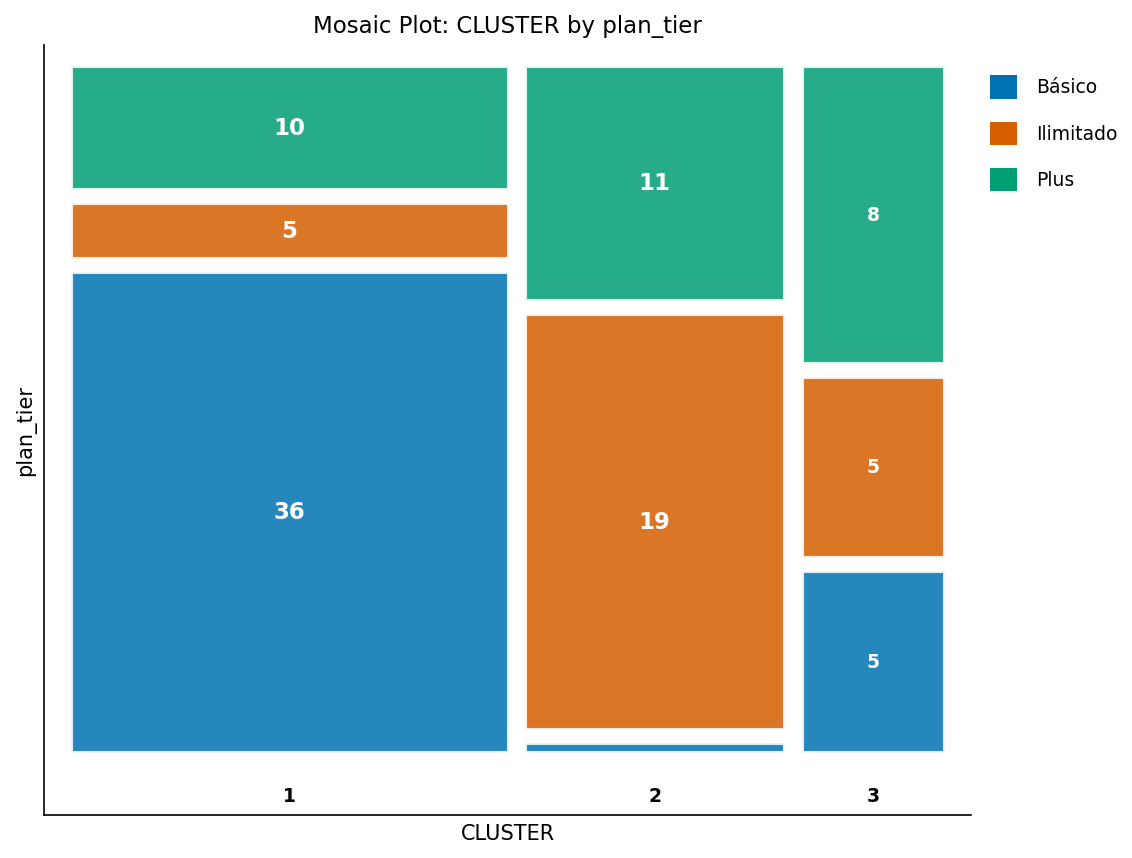

In [5]:
PROCEDIMENTO ORDENAR DADOS=scored out=scored_keys(MANTER=cust_id CLUSTER);
    POR cust_id;
EXECUTAR;

PROCEDIMENTO ORDENAR DADOS=subscribers out=subs_sorted;
    POR cust_id;
EXECUTAR;

DADOS profile;
    MESCLAR subs_sorted(IN=a) scored_keys(IN=b);
    POR cust_id;
    SE a E_LÓGICO b;
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=profile mean std MIN MAX maxdec=1;
    CLASSE CLUSTER;
    VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    RÓTULO CLUSTER='Segmento' tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
          voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
          support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
    TÍTULO 'Perfis dos Segmentos: Uso Médio por Cluster (Unidades Originais)';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    RÓTULO CLUSTER='Segmento' plan_tier='Nível do Plano';
    TÍTULO 'Mix de Nível de Plano em Cada Segmento';
EXECUTAR;

## Etapa 6 - Reaplicar o modelo à captura do próximo mês

Uma segmentação só é útil se puder ser reaplicada sem reexecutar todo o job. Os centroides que salvamos em `SEG_SEEDS` na Etapa 4 são um modelo portátil: reintroduzi-los como `SEED=SEG_SEEDS` com `MAXITER=0` diz ao FASTCLUS para *atribuir* cada observação ao centroide salvo mais próximo sem mover os centroides - pontuação pura, não reajuste. Aqui repontuamos a mesma captura padronizada para confirmar que o modelo exportado reproduz as atribuições originais; em produção, você apontaria `DATA=` para a captura padronizada do próximo mês.

                                         Mix de Nível de Plano em Cada Segmento                                         


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


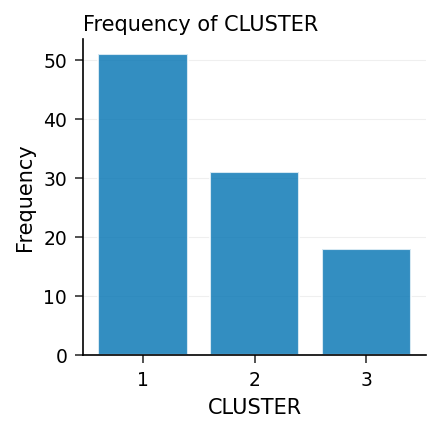

In [6]:
PROCEDIMENTO FASTCLUS DADOS=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VARIÁVEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    RÓTULO tenure_months='Permanência (Meses)' data_gb='Dados (GB)'
          voice_min='Minutos de Voz' intl_min='Minutos Internacionais'
          support_calls='Chamadas de Suporte' monthly_charge='Cobrança Mensal';
    TÍTULO 'Pontuando um Novo Snapshot a partir dos Centroides Exportados';
EXECUTAR;

PROCEDIMENTO FREQUÊNCIAS DADOS=rescored;
    TABLES CLUSTER / nocum;
    RÓTULO CLUSTER='Segmento';
    TÍTULO 'Assinantes Repontuados via o Modelo Exportado';
EXECUTAR;

## Interpretando os resultados

O FASTCLUS recuperou os três segmentos comportamentais embutidos nos dados, e as tabelas de perfilamento os traduzem em um plano de ação de retenção. Leia os números dos segmentos na tabela *Perfis dos Segmentos* acima - os rótulos de cluster são arbitrários, então identifique cada persona pela sua assinatura de uso:

- **Usuários leve/econômico** - pouco dado, contas modestas, permanência mais longa, muito poucas chamadas de suporte, majoritariamente no *Básico*. Esses clientes são estáveis e sensíveis a preço; a decisão certa é *proteger a margem*, não dar desconto. Uma recomendação de plano bem dimensionado evita o choque na fatura sem concessões.
- **Streamers de dados intensos** - muito dado, minutos altos de voz e internacionais, contas premium, majoritariamente *Ilimitado*. São leais e de alto valor: a jogada é *upsell e upgrade de aparelhos*, além de mensagens proativas sobre qualidade de rede para que a promoção de um concorrente não os atraia.
- **Alto contato/em risco** - permanência curta, volume elevado de chamadas de suporte, gasto de nível médio. Os contatos frequentes de atendimento somados à baixa permanência são precursores clássicos de cancelamento (churn). Este é o segmento que merece uma *oferta de retenção proativa* e um acompanhamento de recuperação de serviço.

Escolhas de procedimento que tornaram isso confiável: **PROC STDIZE** impediu que os minutos de voz, de alta magnitude, sufocassem o sinal das chamadas de suporte; a varredura de pseudo-F justificou o número de clusters em vez de adivinhá-lo; o peso `FREQ` fez com que contas familiares com várias linhas contassem proporcionalmente ao seu tamanho; e o ciclo `OUTSEED=`/`SEED=` exportou os centroides para que a equipe de marketing possa ressegmentar cada captura mensal com uma única chamada `MAXITER=0` do FASTCLUS - sem necessidade de reagrupar.